# SVD — Singular Value Decomposition (from scratch)

Every matrix hides a secret structure. SVD reveals it.

Think of any matrix as a transformation — it stretches, rotates, and flips space. SVD breaks that transformation into exactly **three simple steps**:

1. **Rotate** (Vᵀ) — align with the matrix's "natural axes"
2. **Stretch** (Σ) — scale along each axis (these are the singular values)
3. **Rotate again** (U) — orient into the output space

**A = U · Σ · Vᵀ**

| Component | Shape | What it is |
|-----------|-------|------------|
| **U** | m × m | Left singular vectors (orthonormal columns) |
| **Σ** | m × n | Diagonal matrix of singular values (σ₁ ≥ σ₂ ≥ ...) |
| **V** | n × n | Right singular vectors (orthonormal columns) |

The magical part? The singular values (Σ) tell you **how important** each direction is. The biggest one captures the most "energy." Throw away the small ones and you still keep a great approximation — that's how image compression, Netflix recommendations, and noise removal work.

## How we build it from scratch

Power iteration needs a **square** matrix, but A may not be square (e.g., 100×2). The trick:

1. Compute **AᵀA** — always square (n × n) and symmetric, even if A isn't
2. Find eigenvectors of AᵀA using **power iteration + deflation** → columns of **V**
3. Singular values: **σᵢ = √λᵢ** (square roots of eigenvalues of AᵀA)
4. Left singular vectors: **uᵢ = A · vᵢ / σᵢ** → columns of **U**

### Power Iteration
Finds the dominant eigenvector by repeatedly multiplying a random vector and normalizing:
`v ← Mv / ||Mv||` until convergence. Like a compass finding north.

### Finding the Eigenvalue (Rayleigh Quotient)
Once you have an eigenvector `v` (unit length), find its eigenvalue `λ` by projecting the matrix onto it:
`λ = vᵀ · M · v`

### Deflation
Removes the found eigenvector's contribution to find the next one:
`M_deflated = M - λᵢ · vᵢ · vᵢᵀ` — peel the matrix like an onion, layer by layer.

In [67]:
import numpy as np
import math

In [68]:
A = np.array([[2, 1], [1, 2]])
A

array([[2, 1],
       [1, 2]])

In [69]:
def power_iteration(M, num_iters, v):
    if num_iters == 0:
        return v

    v_new = np.dot(M, v)
    v_new = v_new / np.linalg.norm(v_new)

    if np.allclose(v, v_new):
        return v_new
    
    return power_iteration(M, num_iters - 1, v_new)

In [70]:
e_v1 = power_iteration(A, 1000, np.random.random(2))
e_v1

array([0.70710908, 0.70710449])

In [71]:
e_val1 = np.dot(np.dot(np.transpose(e_v1), A), e_v1)
e_val1

np.float64(2.999999999978913)

In [72]:
A_deflated = A - e_val1 * np.outer(e_v1, np.transpose(e_v1))
A_deflated

array([[ 0.49999026, -0.5       ],
       [-0.5       ,  0.50000974]])

In [73]:
e_v2 = power_iteration(A_deflated, 10, np.random.random(2))
e_v2

array([ 0.70709989, -0.70711367])

In [74]:
e_val2 = np.dot(np.dot(np.transpose(e_v2), A_deflated), e_v2)
e_val2

np.float64(1.0000000000632643)

In [75]:
A_deflated_2 = A - e_val2 * np.outer(e_v2, np.transpose(e_v2))
A_deflated_2

array([[1.50000974, 1.5       ],
       [1.5       , 1.49999026]])

In [76]:
AtA = np.array(A).T @ np.array(A)
AtA

array([[5, 4],
       [4, 5]])

In [77]:
Ata_e_v1 = power_iteration(AtA, 10, np.random.random(2))
Ata_e_val1 = np.dot(np.dot(np.transpose(Ata_e_v1), AtA), Ata_e_v1)
Ata_e_v1, Ata_e_val1


(array([0.70710732, 0.70710624]), np.float64(8.999999999995339))

In [78]:
Ata_deflated = AtA - Ata_e_val1 * np.outer(Ata_e_v1, np.transpose(Ata_e_v1))
Ata_deflated

array([[ 0.49999313, -0.5       ],
       [-0.5       ,  0.50000687]])

In [79]:
Ata_e_v2 = power_iteration(Ata_deflated, 10, np.random.random(2))
Ata_e_val2 = np.dot(np.dot(np.transpose(Ata_e_v2), Ata_deflated), Ata_e_v2)
Ata_e_v2, Ata_e_val2

(array([ 0.70710192, -0.70711164]), np.float64(1.0000000000419575))

In [80]:
V = np.column_stack([Ata_e_v1, Ata_e_v2])
V

array([[ 0.70710732,  0.70710192],
       [ 0.70710624, -0.70711164]])

In [81]:
sigma1 = math.sqrt(Ata_e_val1)
sigma2 = math.sqrt(Ata_e_val2)
sigma1, sigma2

(2.9999999999992233, 1.0000000000209788)

In [82]:
u1 = A @ V[:, 0] / sigma1
u2 = A @ V[:, 1] / sigma2
u1, u2

(array([0.70710696, 0.7071066 ]), array([ 0.70709221, -0.70712136]))

In [83]:
U = np.column_stack([u1, u2])
U

array([[ 0.70710696,  0.70709221],
       [ 0.7071066 , -0.70712136]])

In [84]:
sigmas = [sigma1, sigma2]

U @ np.diag(sigmas) @ np.transpose(V)

array([[1.99998779, 1.00000611],
       [0.99999389, 2.00001221]])

Generalizing 

In [85]:
def power_iteration(matrix, v, num_iters = 1000):
	if num_iters == 0:
		return v

	v_new = np.dot(matrix, v)
	v_new = v_new / np.linalg.norm(v_new)

	if np.allclose(v, v_new):
		return v
	
	return power_iteration(matrix, v_new, num_iters - 1)

def eigen_value(matrix, v):
	return np.dot(v.T, np.dot(matrix, v))

def calculate_eigenvalues(matrix: list[list[float|int]]) -> list[float]:
	eigenvalues = []
	M = np.array(matrix)
	m, n = M.shape
	if m != n:
		raise ValueError("Input must be a square matrix")
	num = n
	while num:
		e_vec = power_iteration(M, np.random.random(n))
		e_val = eigen_value(M, e_vec)
		eigenvalues.append(round(float(e_val), 2))
		M = M - e_val * np.outer(e_vec, e_vec)
		num = num - 1

	return eigenvalues

In [86]:
calculate_eigenvalues([[2, 1], [1, 2]])

[3.0, 1.0]

In [87]:
# calculate_eigenvalues([[4, -2, 1], [1, 1, 2]])
# throws ValueError: Input must be a square matrix

In [88]:
# Need to be tweaked so it works for tall matrices; failing case below
def svd(M):
    r, c = M.shape
    if r > c:
        M2 = M.T @ M
        is_tall = True
    else:
        M2 = M @ M.T
        is_tall = False
    n, n = M2.shape
    num = n
    eigen_values = []
    eigen_vectors = []
    sigmas = []
    us = []
    for _ in range(num):
        e_vec = power_iteration(M2, np.random.random(n))
        e_val = eigen_value(M2, e_vec)
        eigen_values.append(e_val)
        eigen_vectors.append(e_vec)
        sigma = np.sqrt(e_val)
        sigmas.append(sigma)
        temp = e_vec / sigma
        u = np.dot(M.T, temp)
        us.append(u)
        M2 = M2 - e_val * np.outer(e_vec, e_vec)

    # print(sigmas)
    # print(us)

    U = np.column_stack(us)
    S = sigmas
    Ev = np.column_stack(eigen_vectors)
    
    return Ev, S, U 

In [89]:
svd(np.array(M))

(array([[ 0.97014223, -0.24254044],
        [ 0.24253672,  0.9701413 ]]),
 [np.float64(4.6904157598211205), np.float64(2.2360679775211074)],
 array([[ 8.79049073e-01, -9.15952994e-06],
        [-3.61961033e-01,  6.50795145e-01],
        [ 3.10253023e-01,  7.59253370e-01]]))

In [90]:
M = [[4, -2, 1], [1, 1, 2]]
U, S, Vh = np.linalg.svd(M)
U, S, Vh

(array([[-0.9701425 , -0.24253563],
        [-0.24253563,  0.9701425 ]]),
 array([4.69041576, 2.23606798]),
 array([[-8.79049073e-01,  3.61961383e-01, -3.10252614e-01],
        [-2.14384819e-17,  6.50791373e-01,  7.59256602e-01],
        [-4.76731295e-01, -6.67423812e-01,  5.72077554e-01]]))

Here are the deep technical details of SVD (A = U * S * V.T).

1. V (Right Singular Vectors)
Construction: These are the orthonormal eigenvectors of (A_transpose * A).
Space: They form an orthonormal basis for the Row Space of A.
Significance: They represent the principal directions in the input space. When you multiply a unit sphere by matrix A, it gets stretched into an ellipsoid. The vectors in V are the directions in the original space that align with the axes of that new ellipsoid.
Relationship: (A_transpose * A) * v_i = (sigma_i^2) * v_i.
2. U (Left Singular Vectors)
Construction: These are the orthonormal eigenvectors of (A * A_transpose).
Space: They form an orthonormal basis for the Column Space of A.
Significance: They represent the principal directions in the output space. They are the actual axes (directions) of the ellipsoid created after the transformation.
Relationship: (A * A_transpose) * u_i = (sigma_i^2) * u_i.
3. S (Singular Values - Diagonal Sigma)
Construction: The square roots of the eigenvalues of (A_transpose * A) or (A * A_transpose).
Significance: They represent the magnitudes of the stretch along each principal axis.
sigma_1 is the length of the longest axis.
sigma_n is the length of the shortest.
Energy: The sum of squares of singular values equals the total variance (Frobenius norm) of the matrix.
Why this is scientifically "Beautifyl":
The Eckart-Young Theorem (Compression)
If you want the absolute best "summary" of a matrix using only k dimensions, SVD gives it to you. You simply keep the first k singular values and zero out the rest.

A_k = sum(sigma_i * u_i * v_i.transpose) for i up to k.
This is how JPEG compression works, how noise is removed from signals, and how latent semantic analysis (LSA) finds "topics" in text.
The Pseudo-inverse (Solving Systems)
For non-square or singular matrices where you can't compute a normal inverse (A^-1), SVD gives you the Moore-Penrose Pseudo-inverse:

A_plus = V * S_inverse * U_transpose
This is the math behind np.linalg.lstsq. It finds the "best fit" solution for any linear system, even if it's overdetermined or underdetermined.
Condition Number (Stability)
The ratio sigma_max / sigma_min tells you how "unstable" your matrix is.

If the ratio is huge, your matrix is nearly singular (fragile).
Small changes in input will cause massive, unpredictable changes in output. SVD is the most reliable way to detect this.

In [91]:
# A 3x2 matrix (Tall)
M_tall = np.array([
    [1, 2],
    [3, 4],
    [5, 6]
])
U, S, Vt = svd(M_tall)

ValueError: shapes (2,3) and (2,) not aligned: 3 (dim 1) != 2 (dim 0)

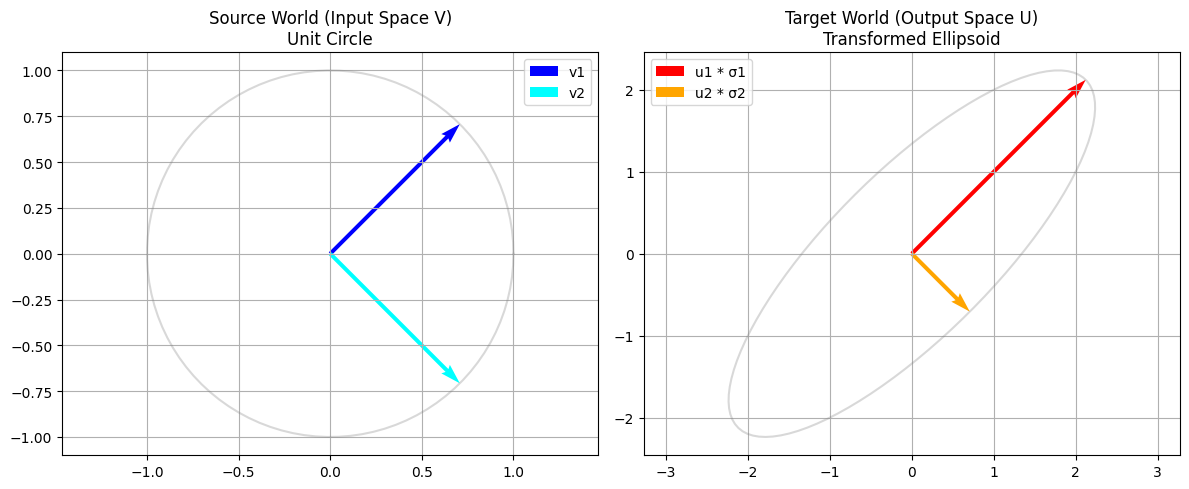

In [ ]:
import matplotlib.pyplot as plt

# 1. Setup a simple transformation matrix A
A_viz = np.array([[2, 1], [1, 2]])
U_viz, S_viz, Vt_viz = svd(A_viz) # Using your custom SVD!
V_viz = Vt_viz.T

# 2. Create a unit circle (the "Source")
theta = np.linspace(0, 2*np.pi, 100)
circle = np.array([np.cos(theta), np.sin(theta)])

# 3. Transform the circle (the "Target")
transformed_circle = A_viz @ circle

# 4. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Source World (V) ---
ax1.plot(circle[0], circle[1], color='gray', alpha=0.3)
# Plot V vectors
ax1.quiver(0, 0, V_viz[0,0], V_viz[1,0], color='blue', scale=1, scale_units='xy', label='v1')
ax1.quiver(0, 0, V_viz[0,1], V_viz[1,1], color='cyan', scale=1, scale_units='xy', label='v2')
ax1.set_title("Source World (Input Space V)\nUnit Circle")
ax1.axis('equal')
ax1.grid(True)
ax1.legend()

# --- Target World (U * Sigma) ---
ax2.plot(transformed_circle[0], transformed_circle[1], color='gray', alpha=0.3)
# Plot U * Sigma vectors (The actual axes of the ellipsoid)
ax2.quiver(0, 0, U_viz[0,0]*S_viz[0], U_viz[1,0]*S_viz[0], color='red', scale=1, scale_units='xy', label='u1 * σ1')
ax2.quiver(0, 0, U_viz[0,1]*S_viz[1], U_viz[1,1]*S_viz[1], color='orange', scale=1, scale_units='xy', label='u2 * σ2')
ax2.set_title("Target World (Output Space U)\nTransformed Ellipsoid")
ax2.axis('equal')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()